# Two-Model + Time-Based K-Fold

**Base:** Two-model approach (0.2633)
**Change:** Instead of single train/val split, use 4 time-based folds.

Each fold trains on more data, and test predictions are averaged across all folds.
This creates a more diverse and robust ensemble.

- H1, H25: Combined K-Fold
- H3, H10: Two-model K-Fold (precision + range per fold)

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import gc
import warnings
import os
warnings.filterwarnings('ignore')

print('Libraries imported')

Libraries imported


In [2]:
TRAIN_PATH = '/kaggle/input/competitions/ts-forecasting/train.parquet'
TEST_PATH = '/kaggle/input/competitions/ts-forecasting/test.parquet'

if not os.path.exists(TRAIN_PATH):
    local_train = os.path.join('data', 'raw', 'train.parquet')
    local_test = os.path.join('data', 'raw', 'test.parquet')
    TRAIN_PATH = local_train if os.path.exists(local_train) else 'train.parquet'
    TEST_PATH = local_test if os.path.exists(local_test) else 'test.parquet'

FORECAST_WINDOWS = [1, 3, 10, 25]
TWO_MODEL_HORIZONS = {3, 10}

# Time-based K-Fold splits
# Each fold: train up to cutoff, validate on the next segment
# Final model for test predictions uses ALL folds
FOLDS = [
    {'train_end': 2800, 'val_start': 2801, 'val_end': 3100},
    {'train_end': 3100, 'val_start': 3101, 'val_end': 3350},
    {'train_end': 3350, 'val_start': 3351, 'val_end': 3601},
]

# For final test predictions, train on everything
FULL_TRAIN_END = 3601

RANGE_PARAMS = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.015, 'n_estimators': 4200,
    'num_leaves': 80, 'min_child_samples': 200,
    'feature_fraction': 0.6, 'bagging_fraction': 0.7,
    'bagging_freq': 5, 'lambda_l1': 0.1, 'lambda_l2': 10.0,
    'verbosity': -1
}

PRECISION_PARAMS = {
    'objective': 'huber', 'metric': 'rmse',
    'learning_rate': 0.01, 'n_estimators': 5000,
    'num_leaves': 100, 'min_child_samples': 80,
    'feature_fraction': 0.7, 'bagging_fraction': 0.75,
    'bagging_freq': 5, 'lambda_l1': 0.01, 'lambda_l2': 2.0,
    'huber_delta': 0.01, 'verbosity': -1
}

SEEDS = [42, 2024, 12345]

print(f'Config: {len(FOLDS)} folds x {len(SEEDS)} seeds = {len(FOLDS) * len(SEEDS)} models per horizon')

Config: 3 folds x 3 seeds = 9 models per horizon


In [3]:
def add_lag_features(df, value_cols=['feature_al', 'feature_am', 'feature_cg', 'feature_by'], lags=[1, 3, 5, 10, 25]):
    df = df.sort_values(['code', 'sub_code', 'sub_category', 'horizon', 'ts_index'])
    for col in value_cols:
        for lag in lags:
            df[f'{col}_lag_{lag}'] = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'])[col].shift(lag)
    return df

def add_rolling_features(df, value_cols=['feature_al', 'feature_am'], windows=[5, 10, 20]):
    df = df.sort_values(['code', 'sub_code', 'sub_category', 'horizon', 'ts_index'])
    for col in value_cols:
        for window in windows:
            df[f'{col}_roll_mean_{window}'] = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'])[col].transform(lambda x: x.rolling(window, min_periods=1).mean())
            df[f'{col}_roll_std_{window}'] = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'])[col].transform(lambda x: x.rolling(window, min_periods=1).std())
    return df

def add_trend_features(df, value_cols=['feature_al', 'feature_am'], windows=[10, 20]):
    df = df.sort_values(['code', 'sub_code', 'sub_category', 'horizon', 'ts_index'])
    def rolling_slope(series, window):
        def calc_slope(y):
            if len(y) < 2:
                return 0
            x = np.arange(len(y))
            return np.polyfit(x, y, 1)[0] if len(y) > 1 else 0
        return series.rolling(window, min_periods=2).apply(calc_slope, raw=True)
    for col in value_cols:
        for window in windows:
            df[f'{col}_trend_{window}'] = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'])[col].transform(lambda x: rolling_slope(x, window))
    return df

def build_enhanced_features(data, enc_stats=None):
    df = data.copy()
    if enc_stats is not None:
        for c in ['sub_category', 'sub_code']:
            df[c + '_enc'] = df[c].map(enc_stats[c]).fillna(enc_stats['global_mean'])

    df['d_al_am'] = df['feature_al'] - df['feature_am']
    df['r_al_am'] = df['feature_al'] / (df['feature_am'] + 1e-7)
    df['d_cg_by'] = df['feature_cg'] - df['feature_by']
    df['p_am_bz'] = df['feature_am'] * df['feature_bz']
    df['p_am_cd'] = df['feature_am'] * df['feature_cd']
    df['d_j_bz']  = df['feature_j']  - df['feature_bz']
    df['r_l_bq']  = df['feature_l']  / (df['feature_bq'] + 1e-7)

    norm_cols = [
        'feature_al', 'feature_am', 'feature_cg', 'feature_by', 'd_al_am',
        'p_am_bz', 'p_am_cd', 'd_j_bz', 'r_l_bq'
    ]
    for col in norm_cols:
        if col in df.columns:
            g = df.groupby('ts_index')[col]
            df[col + '_cs'] = (df[col] - g.transform('mean')) / (g.transform('std') + 1e-7)

    df['t_cycle'] = np.sin(2 * np.pi * df['ts_index'] / 100)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_trend_features(df)

    for col in ['feature_al', 'feature_am']:
        df[f'{col}_diff_1'] = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'])[col].diff(1)
        df[f'{col}_rank'] = df.groupby('ts_index')[col].rank(pct=True)

    for col in ['feature_bz', 'feature_cg', 'd_al_am']:
        if col in df.columns:
            df[f'{col}_rank'] = df.groupby('ts_index')[col].rank(pct=True)

    df = df.fillna(0)
    return df

def get_feature_columns(df):
    exclude_cols = {'id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'weight', 'y_target'}
    return [c for c in df.columns if c not in exclude_cols]

print('Feature engineering ready')

Feature engineering ready


In [4]:
def weighted_rmse_score(y_target, y_pred, w):
    y_target = np.array(y_target)
    y_pred = np.array(y_pred)
    w = np.array(w)
    denom = np.sum(w * (y_target ** 2))
    if denom <= 0:
        return 0.0
    numerator = np.sum(w * ((y_target - y_pred) ** 2))
    ratio = numerator / denom
    return float(np.sqrt(1.0 - np.clip(ratio, 0.0, 1.0)))

print('Metric ready')

Metric ready


In [5]:
print('Computing statistics...')
temp = pd.read_parquet(TRAIN_PATH, columns=['code', 'sub_category', 'sub_code', 'weight', 'y_target', 'ts_index'])

code_weight = temp.groupby('code')['weight'].sum()
total_weight = code_weight.sum()
code_weight_pct = (code_weight / total_weight * 100).sort_values(ascending=False)
cumsum = 0
HIGH_WEIGHT_CODES = []
for code, pct in code_weight_pct.items():
    HIGH_WEIGHT_CODES.append(code)
    cumsum += pct
    if cumsum >= 90:
        break
print(f'High-weight codes ({cumsum:.1f}%): {HIGH_WEIGHT_CODES}')

# Use first fold's train data for encoding stats
train_only = temp[temp.ts_index <= FOLDS[0]['train_end']]
train_stats = {
    'sub_category': train_only.groupby('sub_category')['y_target'].mean().to_dict(),
    'sub_code': train_only.groupby('sub_code')['y_target'].mean().to_dict(),
    'global_mean': train_only['y_target'].mean()
}
del temp, train_only
gc.collect()
print('Statistics computed')

Computing statistics...
High-weight codes (97.8%): ['83EG83KQ', 'SJZP0OVU', 'MLAAMU3K']
Statistics computed


In [6]:
def train_fold_models(X_fit, y_fit, w_fit, X_hold, y_hold, w_hold, te_features, params, seeds, label):
    """Train seed ensemble for one fold, return val and test predictions."""
    val_pred = np.zeros(len(y_hold))
    tst_pred = np.zeros(len(te_features))
    for seed in seeds:
        mdl = lgb.LGBMRegressor(**params, random_state=seed)
        mdl.fit(
            X_fit, y_fit, sample_weight=w_fit,
            eval_set=[(X_hold, y_hold)],
            eval_sample_weight=[w_hold],
            callbacks=[lgb.early_stopping(200, verbose=False)]
        )
        val_pred += mdl.predict(X_hold) / len(seeds)
        tst_pred += mdl.predict(te_features) / len(seeds)
        print(f'      {label} seed {seed}: best_iter={mdl.best_iteration_}')
    del mdl
    gc.collect()
    return val_pred, tst_pred


def train_combined_kfold(tr_df, te_df, feature_cols):
    """K-Fold training for combined model (H1, H25)."""
    tst_pred_sum = np.zeros(len(te_df))
    fold_scores = []

    for fi, fold in enumerate(FOLDS):
        print(f'\n  --- Fold {fi+1}/{len(FOLDS)} (train<={fold["train_end"]}, val={fold["val_start"]}-{fold["val_end"]}) ---')
        fit_mask = tr_df.ts_index <= fold['train_end']
        val_mask = (tr_df.ts_index >= fold['val_start']) & (tr_df.ts_index <= fold['val_end'])

        if val_mask.sum() == 0:
            print('  No val samples, skipping')
            continue

        val_pred, tst_pred = train_fold_models(
            tr_df.loc[fit_mask, feature_cols], tr_df.loc[fit_mask, 'y_target'],
            tr_df.loc[fit_mask, 'weight'].values,
            tr_df.loc[val_mask, feature_cols], tr_df.loc[val_mask, 'y_target'],
            tr_df.loc[val_mask, 'weight'].values,
            te_df[feature_cols], RANGE_PARAMS, SEEDS, f'F{fi+1}'
        )
        tst_pred_sum += tst_pred
        fold_score = weighted_rmse_score(tr_df.loc[val_mask, 'y_target'], val_pred, tr_df.loc[val_mask, 'weight'])
        fold_scores.append(fold_score)
        print(f'    Fold {fi+1} score: {fold_score:.5f}')

    tst_pred_avg = tst_pred_sum / len(FOLDS)
    avg_score = np.mean(fold_scores)
    print(f'\n  Average CV score: {avg_score:.5f}')
    return tst_pred_avg, te_df['id'].values, avg_score, fold_scores


def train_two_model_kfold(tr_df, te_df, feature_cols):
    """K-Fold training for two-model approach (H3, H10)."""
    hw_test = te_df['code'].isin(HIGH_WEIGHT_CODES)
    prec_tst_sum = np.zeros(hw_test.sum())
    range_tst_sum = np.zeros((~hw_test).sum())
    fold_scores = []

    for fi, fold in enumerate(FOLDS):
        print(f'\n  --- Fold {fi+1}/{len(FOLDS)} (train<={fold["train_end"]}, val={fold["val_start"]}-{fold["val_end"]}) ---')
        fit_mask = tr_df.ts_index <= fold['train_end']
        val_mask = (tr_df.ts_index >= fold['val_start']) & (tr_df.ts_index <= fold['val_end'])

        if val_mask.sum() == 0:
            print('  No val samples, skipping')
            continue

        hw_fit = fit_mask & tr_df['code'].isin(HIGH_WEIGHT_CODES)
        hw_val = val_mask & tr_df['code'].isin(HIGH_WEIGHT_CODES)
        lw_fit = fit_mask & ~tr_df['code'].isin(HIGH_WEIGHT_CODES)
        lw_val = val_mask & ~tr_df['code'].isin(HIGH_WEIGHT_CODES)

        # Precision model
        print(f'    PRECISION ({hw_fit.sum():,} train, {hw_val.sum():,} val)')
        prec_val, prec_tst = train_fold_models(
            tr_df.loc[hw_fit, feature_cols], tr_df.loc[hw_fit, 'y_target'],
            tr_df.loc[hw_fit, 'weight'].values,
            tr_df.loc[hw_val, feature_cols], tr_df.loc[hw_val, 'y_target'],
            tr_df.loc[hw_val, 'weight'].values,
            te_df.loc[hw_test, feature_cols], PRECISION_PARAMS, SEEDS, f'P{fi+1}'
        )
        prec_tst_sum += prec_tst

        # Range model
        print(f'    RANGE ({lw_fit.sum():,} train, {lw_val.sum():,} val)')
        range_val, range_tst = train_fold_models(
            tr_df.loc[lw_fit, feature_cols], tr_df.loc[lw_fit, 'y_target'],
            tr_df.loc[lw_fit, 'weight'].values,
            tr_df.loc[lw_val, feature_cols], tr_df.loc[lw_val, 'y_target'],
            tr_df.loc[lw_val, 'weight'].values,
            te_df.loc[~hw_test, feature_cols], RANGE_PARAMS, SEEDS, f'R{fi+1}'
        )
        range_tst_sum += range_tst

        # Merge for fold score
        merged_val = np.zeros(val_mask.sum())
        val_idx = tr_df.index[val_mask]
        hw_val_local = tr_df.loc[val_idx, 'code'].isin(HIGH_WEIGHT_CODES).values
        merged_val[hw_val_local] = prec_val
        merged_val[~hw_val_local] = range_val
        fold_score = weighted_rmse_score(tr_df.loc[val_mask, 'y_target'], merged_val, tr_df.loc[val_mask, 'weight'])
        fold_scores.append(fold_score)
        print(f'    Fold {fi+1} merged score: {fold_score:.5f}')

    # Average test predictions across folds
    merged_tst = np.zeros(len(te_df))
    merged_tst[hw_test.values] = prec_tst_sum / len(FOLDS)
    merged_tst[~hw_test.values] = range_tst_sum / len(FOLDS)

    avg_score = np.mean(fold_scores)
    print(f'\n  Average CV score: {avg_score:.5f}')
    return merged_tst, te_df['id'].values, avg_score, fold_scores


def train_single_horizon(horizon):
    print(f'\n{"="*60}')
    print(f'Training Horizon {horizon}')
    print(f'{"="*60}')

    tr_df = pd.read_parquet(TRAIN_PATH).query(f'horizon == {horizon}')
    te_df = pd.read_parquet(TEST_PATH).query(f'horizon == {horizon}')
    tr_df = build_enhanced_features(tr_df, train_stats)
    te_df = build_enhanced_features(te_df, train_stats)
    feature_cols = get_feature_columns(tr_df)
    print(f'  Features: {len(feature_cols)}')

    if horizon in TWO_MODEL_HORIZONS:
        print(f'  Strategy: TWO-MODEL K-FOLD')
        tst_pred, test_ids, score, fold_scores = train_two_model_kfold(tr_df, te_df, feature_cols)
    else:
        print(f'  Strategy: COMBINED K-FOLD')
        tst_pred, test_ids, score, fold_scores = train_combined_kfold(tr_df, te_df, feature_cols)

    print(f'\n  Horizon {horizon} FINAL CV score: {score:.5f}')

    del tr_df, te_df
    gc.collect()
    return tst_pred, test_ids, score, fold_scores

print('Training function ready — K-Fold')

Training function ready — K-Fold


In [7]:
test_outputs = []
validation_scores = {}
fold_scores_by_horizon = {}

for hz in FORECAST_WINDOWS:
    tst_pred, test_ids, val_score, fold_scores = train_single_horizon(hz)
    test_outputs.append(pd.DataFrame({'id': test_ids, 'prediction': tst_pred}))
    validation_scores[hz] = val_score
    fold_scores_by_horizon[hz] = fold_scores

print('\nAll horizons complete')


Training Horizon 1
  Features: 148
  Strategy: COMBINED K-FOLD

  --- Fold 1/3 (train<=2800, val=2801-3100) ---
      F1 seed 42: best_iter=241
      F1 seed 2024: best_iter=179
      F1 seed 12345: best_iter=569
    Fold 1 score: 0.06091

  --- Fold 2/3 (train<=3100, val=3101-3350) ---
      F2 seed 42: best_iter=146
      F2 seed 2024: best_iter=95
      F2 seed 12345: best_iter=283
    Fold 2 score: 0.04747

  --- Fold 3/3 (train<=3350, val=3351-3601) ---
      F3 seed 42: best_iter=305
      F3 seed 2024: best_iter=111
      F3 seed 12345: best_iter=194
    Fold 3 score: 0.05846

  Average CV score: 0.05561

  Horizon 1 FINAL CV score: 0.05561

Training Horizon 3
  Features: 148
  Strategy: TWO-MODEL K-FOLD

  --- Fold 1/3 (train<=2800, val=2801-3100) ---
    PRECISION (111,520 train, 11,302 val)
      P1 seed 42: best_iter=85
      P1 seed 2024: best_iter=167
      P1 seed 12345: best_iter=106
    RANGE (921,134 train, 120,478 val)
      R1 seed 42: best_iter=157
      R1 seed 20

In [8]:
submission = pd.concat(test_outputs, ignore_index=True)
submission.to_csv('submission.csv', index=False)

print(f'\n{"="*55}')
print(f'{"Horizon":<10} {"Strategy":<18} {"Avg CV Score":<12}')
print('-'*42)
for hz in sorted(validation_scores.keys()):
    strategy = 'TwoModel-KFold' if hz in TWO_MODEL_HORIZONS else 'Combined-KFold'
    print(f'{hz:<10} {strategy:<18} {validation_scores[hz]:<12.5f}')
print('-'*42)
avg_val = np.mean(list(validation_scores.values()))
print(f'{"Avg":<10} {"":<18} {avg_val:<12.5f}')
print(f'{"="*55}')
print(f'\nSaved {len(submission):,} predictions to submission.csv')
print(f'Prev best: 0.2633 (test)')


Horizon    Strategy           Avg CV Score
------------------------------------------
1          Combined-KFold     0.05561     
3          TwoModel-KFold     0.08882     
10         TwoModel-KFold     0.14257     
25         Combined-KFold     0.18812     
------------------------------------------
Avg                           0.11878     

Saved 1,447,107 predictions to submission.csv
Prev best: 0.2633 (test)


In [9]:
%matplotlib inline
# === Visualization Setup ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

FIG_DIR = os.path.join('report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Load metadata for both train and test
train_meta = pd.read_parquet(TRAIN_PATH, columns=['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight'])
test_meta  = pd.read_parquet(TEST_PATH,  columns=['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index'])
submission_all = pd.concat(test_outputs, ignore_index=True)


def get_series_data(code, sub_code, sub_category, horizon):
    """Pull train + test rows for one (code, sub_code, sub_category, horizon) tuple."""
    tr_mask = (
        (train_meta['code'] == code) & (train_meta['sub_code'] == sub_code)
        & (train_meta['sub_category'] == sub_category) & (train_meta['horizon'] == horizon)
    )
    series_train = train_meta[tr_mask].sort_values('ts_index').reset_index(drop=True)

    te_mask = (
        (test_meta['code'] == code) & (test_meta['sub_code'] == sub_code)
        & (test_meta['sub_category'] == sub_category) & (test_meta['horizon'] == horizon)
    )
    series_test = test_meta[te_mask].sort_values('ts_index').reset_index(drop=True)
    series_test = series_test.merge(submission_all.rename(columns={'prediction': 'y_pred'}), on='id', how='left')
    return series_train, series_test


print('Visualization setup complete')

Visualization setup complete


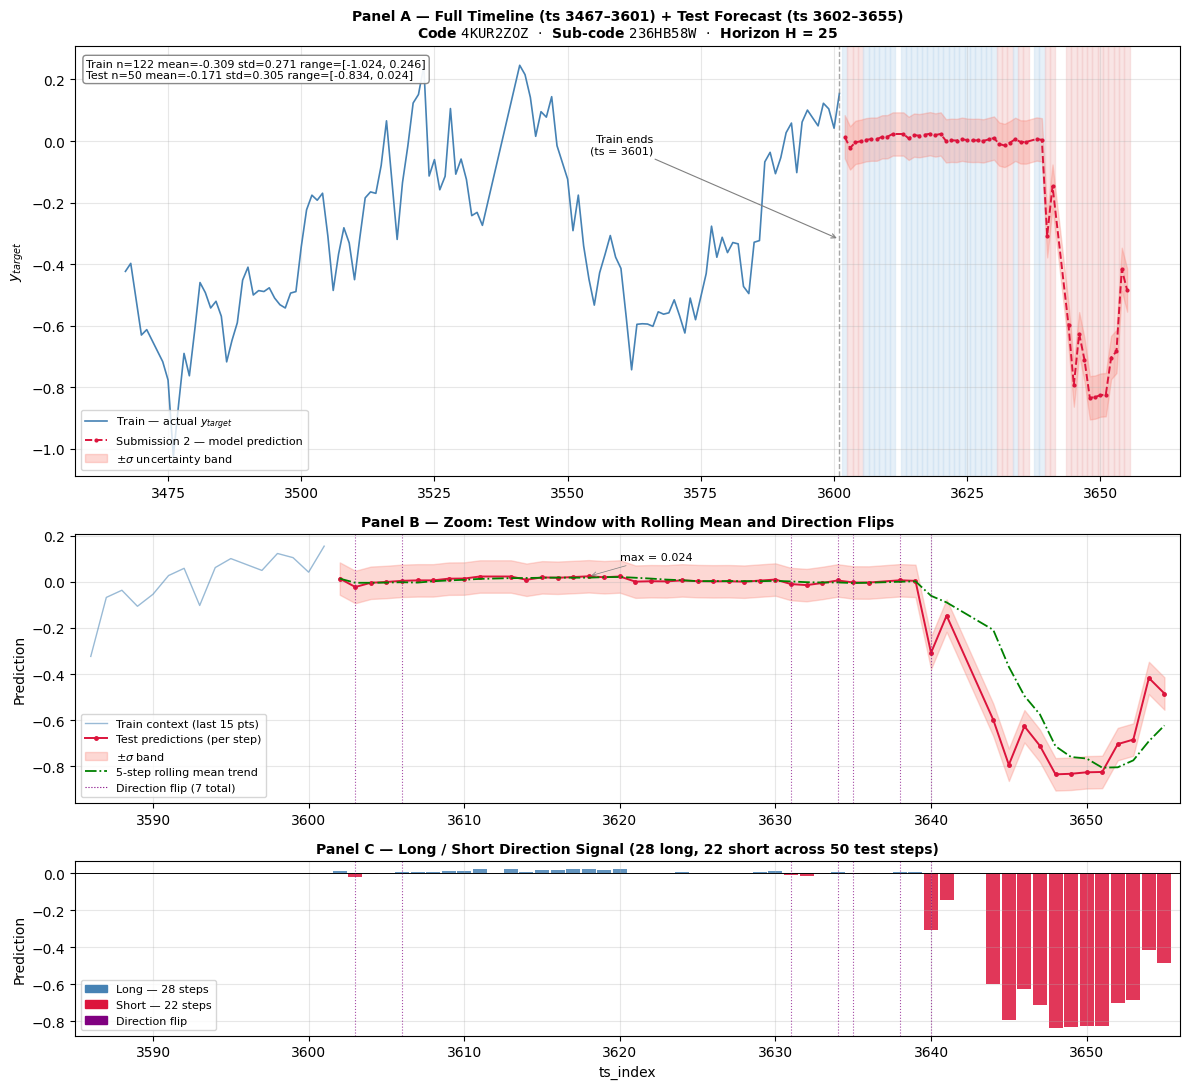

Saved: 08_two_model_submission_forecast


In [10]:
# === Figure: Submission 2 forecast on a volatile series  ===
# Three-panel chart for code 4KUR2ZOZ / H=25:
#   Panel A - full timeline (train + test forecast with sigma band)
#   Panel B - zoom on test window with rolling mean and direction flips
#   Panel C - long/short direction signal bar chart
SEL_CODE_VOL = '4KUR2ZOZ'
SEL_SUB_VOL  = '236HB58W'
SEL_CAT_VOL  = 'PZ9S1Z4V'
SEL_HZ_VOL   = 25

series_train, series_test = get_series_data(SEL_CODE_VOL, SEL_SUB_VOL, SEL_CAT_VOL, SEL_HZ_VOL)

train_x = series_train['ts_index'].to_numpy()
train_y = series_train['y_target'].to_numpy(dtype=float)
test_x  = series_test['ts_index'].to_numpy()
test_y  = series_test['y_pred'].to_numpy(dtype=float)

# +- sigma derived from rolling std of last 10 training observations
sigma = float(pd.Series(train_y[-10:]).std()) if len(train_y) >= 2 else 0.1

# Direction flips
flips = [int(test_x[i]) for i in range(1, len(test_y))
         if (test_y[i-1] >= 0) != (test_y[i] >= 0)]
n_long  = int((test_y > 0).sum())
n_short = int((test_y < 0).sum())
roll5   = pd.Series(test_y).rolling(5, min_periods=1).mean().to_numpy()

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 11),
    gridspec_kw={'height_ratios': [1.6, 1.0, 0.65]}
)

# ---------- Panel A ----------
# Direction-shaded background (light blue for long, light coral for short)
for i, p in enumerate(test_y):
    color = '#cfe2f3' if p >= 0 else '#f4cccc'
    ax1.axvspan(test_x[i] - 0.5, test_x[i] + 0.5, color=color, alpha=0.5)

ax1.plot(train_x, train_y, color='steelblue', lw=1.2, label=r'Train — actual $y_{target}$')
ax1.plot(test_x, test_y,   color='crimson',  lw=1.4, ls='--', marker='.', ms=4,
         label='Submission 2 — model prediction')
ax1.fill_between(test_x, test_y - sigma, test_y + sigma, color='salmon', alpha=0.30,
                 label=r'$\pm\sigma$ uncertainty band')

train_end = int(train_x[-1])
ax1.axvline(train_end, color='gray', lw=1, ls='--', alpha=0.7)
ymin, ymax = ax1.get_ylim()
ax1.annotate(f'Train ends\n(ts = {train_end})',
             xy=(train_end, ymin + 0.55 * (ymax - ymin)),
             xytext=(train_end - 35, ymin + 0.75 * (ymax - ymin)),
             fontsize=8, ha='right',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

stats_train = (f'Train n={len(train_y)} mean={train_y.mean():.3f} '
               f'std={train_y.std():.3f} range=[{train_y.min():.3f}, {train_y.max():.3f}]')
stats_test  = (f'Test n={len(test_y)} mean={test_y.mean():.3f} '
               f'std={test_y.std():.3f} range=[{test_y.min():.3f}, {test_y.max():.3f}]')
ax1.text(0.01, 0.97, stats_train + '\n' + stats_test,
         transform=ax1.transAxes, fontsize=8, va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='gray', alpha=0.92))

ax1.set_ylabel(r'$y_{target}$', fontsize=10)
ax1.set_title(
    f'Panel A — Full Timeline (ts {train_x[0]}–{train_x[-1]}) + '
    f'Test Forecast (ts {test_x[0]}–{test_x[-1]})\n'
    + r'Code $\mathtt{' + SEL_CODE_VOL + r'}$  $\cdot$  '
    + r'Sub-code $\mathtt{' + SEL_SUB_VOL + r'}$  $\cdot$  '
    + f'Horizon H = {SEL_HZ_VOL}',
    fontsize=10, fontweight='bold'
)
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(alpha=0.3)

# ---------- Panel B ----------
context_n = 15
ctx_x = train_x[-context_n:]
ctx_y = train_y[-context_n:]
ax2.plot(ctx_x, ctx_y, color='steelblue', lw=1.0, alpha=0.55,
         label=f'Train context (last {context_n} pts)')
ax2.plot(test_x, test_y, color='crimson', lw=1.4, marker='.', ms=5,
         label='Test predictions (per step)')
ax2.fill_between(test_x, test_y - sigma, test_y + sigma,
                 color='salmon', alpha=0.30, label=r'$\pm\sigma$ band')
ax2.plot(test_x, roll5, color='green', lw=1.3, ls='-.',
         label='5-step rolling mean trend')

for f in flips:
    ax2.axvline(f, color='purple', lw=0.8, ls=':', alpha=0.7)

max_idx = int(np.argmax(test_y))
ax2.annotate(f'max = {test_y[max_idx]:.3f}',
             xy=(test_x[max_idx], test_y[max_idx]),
             xytext=(test_x[max_idx] + 2, test_y[max_idx] + 0.07),
             fontsize=8,
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

handles, labels = ax2.get_legend_handles_labels()
handles.append(plt.Line2D([0], [0], color='purple', lw=0.8, ls=':',
                          label=f'Direction flip ({len(flips)} total)'))
ax2.legend(handles=handles, fontsize=8, loc='lower left')
ax2.set_ylabel('Prediction', fontsize=10)
ax2.set_title('Panel B — Zoom: Test Window with Rolling Mean and Direction Flips',
              fontsize=10, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xlim(ctx_x[0] - 1, test_x[-1] + 1)

# ---------- Panel C ----------
bar_colors = ['steelblue' if p > 0 else 'crimson' for p in test_y]
ax3.bar(test_x, test_y, color=bar_colors, alpha=0.85, width=0.9)
ax3.axhline(0, color='black', lw=0.7)

for f in flips:
    ax3.axvline(f, color='purple', lw=0.8, ls=':', alpha=0.7)

ax3.set_ylabel('Prediction', fontsize=10)
ax3.set_xlabel('ts_index', fontsize=10)
ax3.set_title(
    f'Panel C — Long / Short Direction Signal '
    f'({n_long} long, {n_short} short across {len(test_y)} test steps)',
    fontsize=10, fontweight='bold'
)
ax3.legend(handles=[
    mpatches.Patch(color='steelblue', label=f'Long — {n_long} steps'),
    mpatches.Patch(color='crimson',   label=f'Short — {n_short} steps'),
    mpatches.Patch(color='purple',    label='Direction flip'),
], fontsize=8, loc='lower left')
ax3.grid(alpha=0.3)
ax3.set_xlim(ctx_x[0] - 1, test_x[-1] + 1)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/08_two_model_submission_forecast.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/08_two_model_submission_forecast.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved: 08_two_model_submission_forecast')

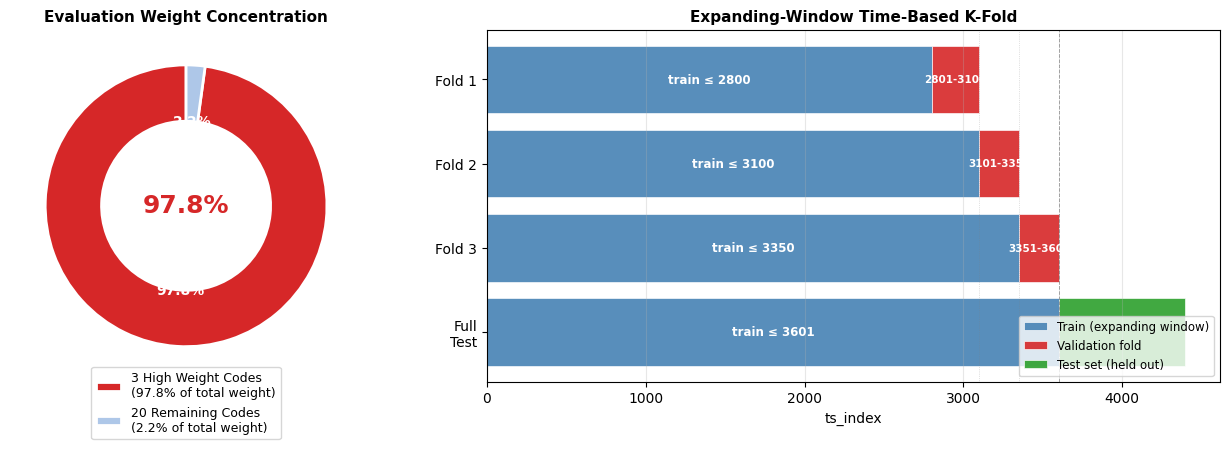

Saved: 08_two_model_weight_kfold


In [11]:
# === Figure: Evaluation weight concentration + K-Fold design ===
# Left  : donut chart of weight share for high-weight codes vs the rest.
# Right : Gantt-style visualisation of the expanding-window K-fold splits.
fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(13, 4.6),
    gridspec_kw={'width_ratios': [1, 1.55]}
)

# ---------- Left: donut chart ----------
high_w_total = float(code_weight_pct.iloc[:len(HIGH_WEIGHT_CODES)].sum())
low_w_total  = float(code_weight_pct.iloc[len(HIGH_WEIGHT_CODES):].sum())

sizes  = [high_w_total, low_w_total]
labels = [
    f'{len(HIGH_WEIGHT_CODES)} High Weight Codes\n({high_w_total:.1f}% of total weight)',
    f'{len(code_weight_pct) - len(HIGH_WEIGHT_CODES)} Remaining Codes\n({low_w_total:.1f}% of total weight)',
]
colors = ['#d62728', '#aec7e8']

wedges, _, autotexts = ax_left.pie(
    sizes, autopct='%1.1f%%', startangle=90, colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white', lw=2),
    textprops=dict(fontsize=10, color='white', fontweight='bold')
)
ax_left.text(0, 0, f'{high_w_total:.1f}%', ha='center', va='center',
             fontsize=18, fontweight='bold', color='#d62728')
ax_left.set_title('Evaluation Weight Concentration', fontweight='bold', fontsize=11)
ax_left.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               fontsize=9, frameon=True)

# ---------- Right: K-Fold Gantt ----------
fold_labels = [f'Fold {i+1}' for i in range(len(FOLDS))] + ['Full\nTest']
test_visual_end = int(FULL_TRAIN_END * 1.22)  # purely cosmetic axis padding for the held-out bar

for i, fold in enumerate(FOLDS):
    train_end = fold['train_end']
    val_start = fold['val_start']
    val_end   = fold['val_end']

    ax_right.barh(i, train_end, color='steelblue', alpha=0.9, edgecolor='white', lw=0.5,
                  label='Train (expanding window)' if i == 0 else None)
    ax_right.barh(i, val_end - val_start, left=val_start, color='#d62728',
                  alpha=0.9, edgecolor='white', lw=0.5,
                  label='Validation fold' if i == 0 else None)
    ax_right.text(train_end / 2, i, f'train ≤ {train_end}', ha='center', va='center',
                  color='white', fontsize=8.5, fontweight='bold')
    ax_right.text((val_start + val_end) / 2, i, f'{val_start}-{val_end}',
                  ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')

# Final test row
ti = len(FOLDS)
ax_right.barh(ti, FULL_TRAIN_END, color='steelblue', alpha=0.9, edgecolor='white', lw=0.5)
ax_right.barh(ti, test_visual_end - FULL_TRAIN_END, left=FULL_TRAIN_END,
              color='#2ca02c', alpha=0.9, edgecolor='white', lw=0.5,
              label='Test set (held out)')
ax_right.text(FULL_TRAIN_END / 2, ti, f'train ≤ {FULL_TRAIN_END}',
              ha='center', va='center', color='white', fontsize=8.5, fontweight='bold')

# Cutoff guide lines
for fold in FOLDS:
    ax_right.axvline(fold['val_end'], color='gray', lw=0.5, ls=':', alpha=0.45)
ax_right.axvline(FULL_TRAIN_END, color='gray', lw=0.7, ls='--', alpha=0.7)

ax_right.set_yticks(range(len(fold_labels)))
ax_right.set_yticklabels(fold_labels)
ax_right.invert_yaxis()
ax_right.set_xlabel('ts_index', fontsize=10)
ax_right.set_title('Expanding-Window Time-Based K-Fold', fontweight='bold', fontsize=11)
ax_right.legend(fontsize=8.5, loc='lower right')
ax_right.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/08_two_model_weight_kfold.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/08_two_model_weight_kfold.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved: 08_two_model_weight_kfold')

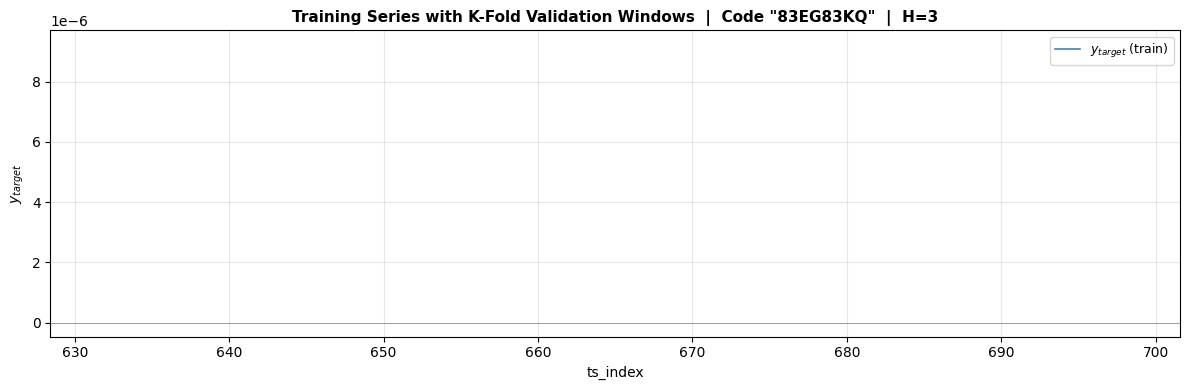

Saved: 08_two_model_train_history (n_train=1)


In [12]:
# === Figure: Training history with K-Fold validation windows ===
# Code 83EG83KQ at H=3 - the highest-weight code on a two-model horizon.
SEL_CODE_HW = '83EG83KQ'
SEL_HZ_HW   = 3

# Pick the highest-weight (sub_code, sub_category) combination for this code/horizon.
hw_subset = train_meta[(train_meta['code'] == SEL_CODE_HW) & (train_meta['horizon'] == SEL_HZ_HW)]
key_w = (hw_subset.groupby(['code', 'sub_code', 'sub_category'])['weight']
         .sum().reset_index().sort_values('weight', ascending=False))
sel_sub_hw = key_w['sub_code'].iloc[0]
sel_cat_hw = key_w['sub_category'].iloc[0]

mask = (
    (train_meta['code'] == SEL_CODE_HW) & (train_meta['sub_code'] == sel_sub_hw)
    & (train_meta['sub_category'] == sel_cat_hw) & (train_meta['horizon'] == SEL_HZ_HW)
)
series_hw = train_meta[mask].sort_values('ts_index').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series_hw['ts_index'], series_hw['y_target'], color='steelblue', lw=1.2,
        label=r'$y_{target}$ (train)')

# Shade each K-fold validation window where it overlaps with this series.
ts_min = int(series_hw['ts_index'].min())
ts_max = int(series_hw['ts_index'].max())
shaded_any = False
for i, fold in enumerate(FOLDS):
    val_lo = max(fold['val_start'], ts_min)
    val_hi = min(fold['val_end'],   ts_max)
    if val_lo <= val_hi:
        label = f'Val Fold {i+1}' if not shaded_any else None
        ax.axvspan(val_lo, val_hi, color='#d62728', alpha=0.15, label=label)
        shaded_any = True

ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('ts_index', fontsize=10)
ax.set_ylabel(r'$y_{target}$', fontsize=10)
ax.set_title(
    f'Training Series with K-Fold Validation Windows  |  '
    f'Code "{SEL_CODE_HW}"  |  H={SEL_HZ_HW}',
    fontweight='bold', fontsize=11
)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/08_two_model_train_history.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/08_two_model_train_history.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f'Saved: 08_two_model_train_history (n_train={len(series_hw)})')

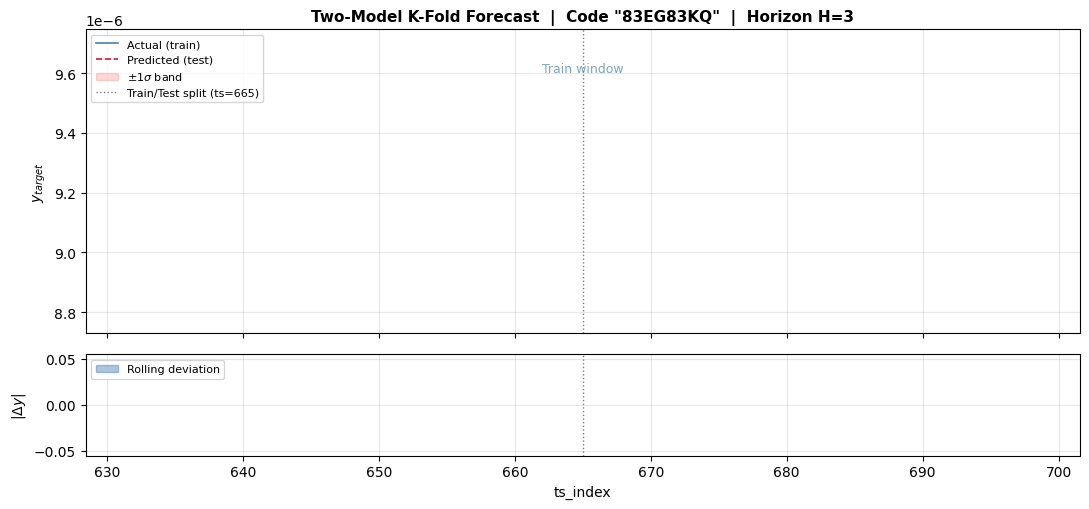

Saved: 08_two_model_combined_timeline


In [13]:
# === Figure: Combined timeline with +-1 sigma band + rolling deviation ===
# Top    - train history + test forecast with +-1 sigma uncertainty band.
# Bottom - rolling absolute deviation of the training series.
series_train_hw, series_test_hw = get_series_data(SEL_CODE_HW, sel_sub_hw, sel_cat_hw, SEL_HZ_HW)

last10_hw = series_train_hw['y_target'].tail(10).to_numpy(dtype=float)
sigma_hw  = float(pd.Series(last10_hw).std()) if len(last10_hw) >= 2 else 0.0

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 5.2), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ---------- Top: forecast ----------
ax_top.plot(series_train_hw['ts_index'], series_train_hw['y_target'],
            color='steelblue', lw=1.2, label='Actual (train)')

test_x_hw = series_test_hw['ts_index'].to_numpy()
test_y_hw = series_test_hw['y_pred'].to_numpy(dtype=float)
ax_top.plot(test_x_hw, test_y_hw, color='crimson', lw=1.2, ls='--',
            label='Predicted (test)')
ax_top.fill_between(test_x_hw, test_y_hw - sigma_hw, test_y_hw + sigma_hw,
                    color='salmon', alpha=0.30, label=r'$\pm 1\sigma$ band')

train_end_hw = int(series_train_hw['ts_index'].max())
ax_top.axvline(train_end_hw, color='gray', lw=1, ls=':',
               label=f'Train/Test split (ts={train_end_hw})')

ymin, ymax = ax_top.get_ylim()
ax_top.text(series_train_hw['ts_index'].mean(), ymin + 0.86 * (ymax - ymin),
            'Train window', ha='center', color='steelblue', fontsize=9, alpha=0.7)
if len(test_x_hw) > 0:
    ax_top.text(test_x_hw.mean(), ymin + 0.86 * (ymax - ymin),
                'Forecast', ha='center', color='crimson', fontsize=9, alpha=0.7)

ax_top.set_ylabel(r'$y_{target}$', fontsize=10)
ax_top.set_title(
    f'Two-Model K-Fold Forecast  |  Code "{SEL_CODE_HW}"  |  Horizon H={SEL_HZ_HW}',
    fontweight='bold', fontsize=11
)
ax_top.legend(fontsize=8, loc='upper left')
ax_top.grid(alpha=0.3)

# ---------- Bottom: rolling deviation ----------
roll_dev = (series_train_hw['y_target']
            .rolling(5, min_periods=1).std().fillna(0).to_numpy())
ax_bot.fill_between(series_train_hw['ts_index'], 0, roll_dev,
                    color='steelblue', alpha=0.45, label='Rolling deviation')
ax_bot.axvline(train_end_hw, color='gray', lw=1, ls=':')
ax_bot.set_xlabel('ts_index', fontsize=10)
ax_bot.set_ylabel(r'$|\Delta y|$', fontsize=10)
ax_bot.legend(fontsize=8, loc='upper left')
ax_bot.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/08_two_model_combined_timeline.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/08_two_model_combined_timeline.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved: 08_two_model_combined_timeline')

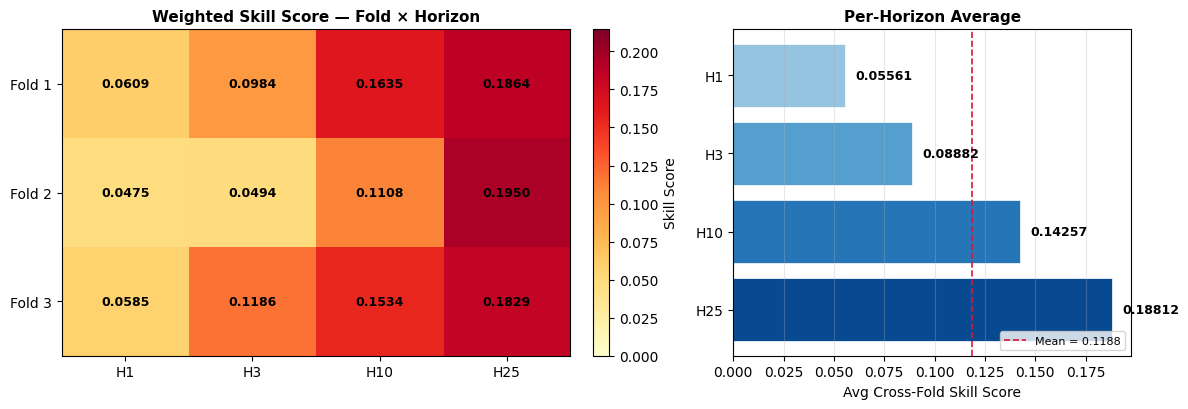

Saved: 08_two_model_fold_scores


In [14]:
# === Figure: Fold x Horizon skill heatmap + per-horizon average ===
# Uses fold_scores_by_horizon populated during training.
horizons_sorted = sorted(FORECAST_WINDOWS)
n_folds_actual  = max(len(fold_scores_by_horizon[h]) for h in horizons_sorted)

# Pad with NaN if any horizon has fewer fold scores than the maximum.
score_matrix = np.full((n_folds_actual, len(horizons_sorted)), np.nan)
for hi, hz in enumerate(horizons_sorted):
    fs = fold_scores_by_horizon[hz]
    for fi, val in enumerate(fs):
        score_matrix[fi, hi] = val

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(12, 4.2),
    gridspec_kw={'width_ratios': [1.4, 1]}
)

# ---------- Left: heatmap ----------
vmax = float(np.nanmax(score_matrix)) * 1.1 if np.isfinite(score_matrix).any() else 1.0
im = ax_left.imshow(score_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
ax_left.set_xticks(range(len(horizons_sorted)))
ax_left.set_xticklabels([f'H{h}' for h in horizons_sorted])
ax_left.set_yticks(range(n_folds_actual))
ax_left.set_yticklabels([f'Fold {i+1}' for i in range(n_folds_actual)])

for fi in range(n_folds_actual):
    for hi in range(len(horizons_sorted)):
        val = score_matrix[fi, hi]
        if np.isfinite(val):
            ax_left.text(hi, fi, f'{val:.4f}', ha='center', va='center',
                         color='black', fontweight='bold', fontsize=9)

ax_left.set_title('Weighted Skill Score — Fold × Horizon',
                  fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax_left, label='Skill Score', fraction=0.046, pad=0.04)

# ---------- Right: per-horizon average ----------
horizon_means = np.nanmean(score_matrix, axis=0)
overall_mean  = float(np.nanmean(horizon_means))

y_pos = list(range(len(horizons_sorted)))
bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(horizons_sorted)))
ax_right.barh(y_pos, horizon_means, color=bar_colors, edgecolor='white', lw=0.5)
ax_right.axvline(overall_mean, color='crimson', ls='--', lw=1.2,
                 label=f'Mean = {overall_mean:.4f}')

for i, val in enumerate(horizon_means):
    ax_right.text(val + 0.005, i, f'{val:.5f}', va='center',
                  fontsize=9, fontweight='bold')

ax_right.set_yticks(y_pos)
ax_right.set_yticklabels([f'H{h}' for h in horizons_sorted])
ax_right.invert_yaxis()
ax_right.set_xlabel('Avg Cross-Fold Skill Score', fontsize=10)
ax_right.set_title('Per-Horizon Average', fontweight='bold', fontsize=11)
ax_right.legend(fontsize=8, loc='lower right')
ax_right.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/08_two_model_fold_scores.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/08_two_model_fold_scores.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved: 08_two_model_fold_scores')